# Pipeline Demo

In this demo, we optimize the simple polynomial function with pipeline.

## Creating the Data Structures

In [1]:
import sys
from enum import IntEnum
from pathlib import Path

import numpy as np

from xilinxutils.codegen.build import CodeGenConfig
from xilinxutils.codegen.streamutils import copy_streamutils
from xilinxutils.hw.dataschema import DataArray, DataList, EnumField, FloatField, IntField
from xilinxutils.hw import toolchain

In [ ]:

INCLUDE_DIR = "include"
WORD_BW_SUPPORTED = [32, 64]
MaxNsamp = 128

Float32 = FloatField.specialize(bitwidth=32)

class PolyError(IntEnum):
    NO_ERROR = 0
    WRONG_NSAMP = 1

PolyErrorField = EnumField.specialize(enum_type=PolyError, include_dir=INCLUDE_DIR)


class CoeffArray(DataArray):
    ncoeffs = 4
    element_type = Float32
    static = True
    max_shape = (ncoeffs,)
    include_dir = INCLUDE_DIR


TransId = IntField.specialize(bitwidth=16, signed=False)
Nsamp = IntField.specialize(bitwidth=16, signed=False)

class PolyCmdHdr(DataList):
    elements = {
        "tx_id": {
            "schema": TransId,
            "description": "Transaction ID",
        },
        "coeffs": {
            "schema": CoeffArray,
            "description": "Polynomial coefficients",
        },
        "nsamp": {
            "schema": Nsamp,
            "description": "Number of samples",
        },
    }
    include_dir = INCLUDE_DIR


class PolyRespHdr(DataList):
    elements = {
        "tx_id": {
            "schema": TransId,
            "description": "Echo of the transaction ID sent in the command",
        },
    }
    include_dir = INCLUDE_DIR


class PolyRespFtr(DataList):
    elements = {
        "nsamp_read": {
            "schema": Nsamp,
            "description": "Number of samples returned in the response",
        },
        "error": {
            "schema": PolyErrorField,
            "description": "Error code indicating success or type of failure",
        },
    }
    include_dir = INCLUDE_DIR


class SampDataIn(DataArray):
    element_type = Float32
    static = False
    max_shape = (MaxNsamp,)
    include_dir = INCLUDE_DIR


class SampDataOut(DataArray):
    element_type = Float32
    static = False
    max_shape = (MaxNsamp,)
    include_dir = INCLUDE_DIR


SCHEMA_CLASSES = [
    PolyErrorField,
    CoeffArray,
    PolyCmdHdr,
    PolyRespHdr,
    PolyRespFtr,
    SampDataIn,
    SampDataOut,
]

## Python Golden Model

In [ ]:
def polynomial_eval(
    cmd_hdr: PolyCmdHdr,
    samp_in: SampDataIn,
) -> tuple[PolyRespHdr, SampDataOut, PolyRespFtr]:
    resp_hdr = PolyRespHdr()
    resp_hdr.tx_id = cmd_hdr.tx_id

    coeffs = np.asarray(cmd_hdr.coeffs, dtype=np.float32)
    x = np.asarray(samp_in.val, dtype=np.float32)
    y = np.zeros_like(x)
    power = np.ones_like(x)
    for coeff in coeffs:
        y += coeff * power
        power *= x

    samp_out = SampDataOut()
    samp_out.val = y

    resp_ftr = PolyRespFtr()
    resp_ftr.nsamp_read = len(x)
    if len(x) == int(cmd_hdr.nsamp):
        resp_ftr.error = PolyError.NO_ERROR 
    else:
        resp_ftr.error = PolyError.WRONG_NSAMP

    return resp_hdr, samp_out, resp_ftr

## Build Test Data

In [4]:
nsamp = 10

coeffs = CoeffArray()
coeffs.val = np.array([1.0, -2.0, -3.0, 4.0], dtype=np.float32)

cmd_hdr = PolyCmdHdr()
cmd_hdr.tx_id = 42
cmd_hdr.coeffs = coeffs.val
cmd_hdr.nsamp = nsamp

samp_in = SampDataIn()
samp_in.val = np.linspace(0.0, 1.0, nsamp, dtype=np.float32)

resp_hdr, samp_out, resp_ftr = polynomial_eval(cmd_hdr, samp_in)

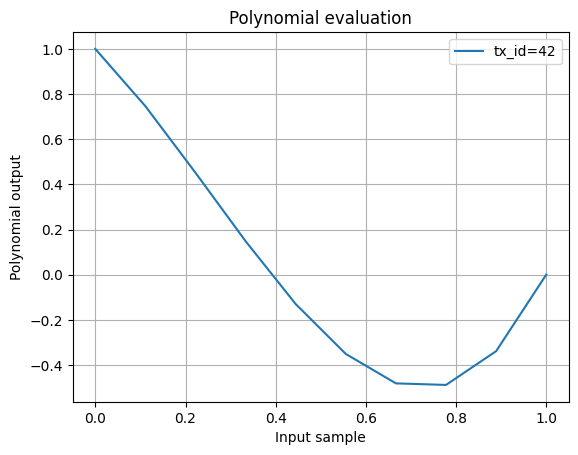

In [5]:
import matplotlib.pyplot as plt
plt.plot(samp_in.val, samp_out.val, label=f"tx_id={cmd_hdr.tx_id}")
plt.xlabel("Input sample")
plt.ylabel("Polynomial output")
plt.title("Polynomial evaluation")
plt.grid(True)
plt.legend()
plt.show()

Write the test vectors to a file

In [6]:

data_dir = Path.cwd() / "data"
data_dir.mkdir(exist_ok=True)
cmd_hdr.write_uint32_file(data_dir / "cmd_hdr_data.bin")
samp_in.write_uint32_file(data_dir / "samp_in_data.bin", nwrite=cmd_hdr.nsamp)
samp_out.write_uint32_file(data_dir / "samp_out_data.bin", nwrite=resp_ftr.nsamp_read)

WindowsPath('c:/Users/sdran/Documents/repos/hwdesign/demos/pipeline/data/samp_out_data.bin')

## Generate the include files

In [7]:
# Make the include directory
include_dir = Path.cwd() / INCLUDE_DIR
include_dir.mkdir(exist_ok=True)

cfg = CodeGenConfig(root_dir=Path.cwd(), util_dir=INCLUDE_DIR)
for schema_class in SCHEMA_CLASSES:
    out_path = schema_class.gen_include(cfg=cfg, word_bw_supported=WORD_BW_SUPPORTED)
    print(f"generated {out_path}")
copy_streamutils(cfg)

generated c:\Users\sdran\Documents\repos\hwdesign\demos\pipeline\include\poly_error.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\pipeline\include\coeff_array.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\pipeline\include\poly_cmd_hdr.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\pipeline\include\poly_resp_hdr.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\pipeline\include\poly_resp_ftr.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\pipeline\include\samp_data_in.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\pipeline\include\samp_data_out.h


('C:\\Users\\sdran\\Documents\\repos\\hwdesign\\demos\\pipeline\\include\\streamutils_hls.h',
 'C:\\Users\\sdran\\Documents\\repos\\hwdesign\\demos\\pipeline\\include\\streamutils_tb.h')

In [15]:
import subprocess

out_path = Path.cwd() / "vitis_run_out.txt"

def write_vitis_output(stdout_text: str | None, stderr_text: str | None) -> None:
    out_path.write_text(
        "STDOUT\n"
        "======\n"
        f"{stdout_text or ''}\n\n"
        "STDERR\n"
        "======\n"
        f"{stderr_text or ''}\n",
        encoding="utf-8",
    )

try:
    resp = toolchain.run_vitis_hls(
        Path.cwd() / "run.tcl",
        work_dir=Path.cwd(),
        capture_output=True,
    )
    write_vitis_output(resp.stdout, resp.stderr)
    print("Vitis run successfully completed")
    print(f"Wrote Vitis output to {out_path}")
except subprocess.CalledProcessError as exc:
    write_vitis_output(exc.stdout, exc.stderr)
    print("Vitis run failed")
    print(f"Wrote Vitis output to {out_path}")
    raise

Vitis run successfully completed
Wrote Vitis output to c:\Users\sdran\Documents\repos\hwdesign\demos\pipeline\vitis_run_out.txt


In [16]:
from xilinxutils.csynthparse import CsynthParser
import os

# Parse the synthesis for UF=1 
sol_path = os.path.join(os.getcwd(), 'poly_proj', 'solution1')
parser = CsynthParser(sol_path=sol_path)

# Get the latency and initiation interval
print('Latency and Initiation Interval:')
parser.get_loop_pipeline_info()
print(parser.loop_df)

# Get the resources
print('\nResource Usage:')
parser.get_resources()
print(parser.res_df)

Latency and Initiation Interval:
                                                 PipelineII  PipelineDepth
poly_Pipeline_VITIS_LOOP_262_1:VITIS_LOOP_262_1           1              2
poly_Pipeline_load_loop:load_loop                         1              2
poly_Pipeline_proc_loop:proc_loop                         1             30
poly_Pipeline_store_loop:store_loop                       1              2

Resource Usage:
                                BRAM_18K  DSP      FF    LUT  URAM
poly_Pipeline_VITIS_LOOP_262_1         0    0     136     73     0
poly_Pipeline_load_loop                0    0      26     95     0
poly_Pipeline_proc_loop                0   30    2940   4535     0
poly_Pipeline_store_loop               0    0      21    151     0
poly                                   4   30    3214   5242     0
Total                                  4   30    3214   5242     0
Available                            280  220  106400  53200     0
